In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import make_scorer, accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import cross_val_score, cross_validate
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load the dataset
dataset_path = "SytheticContradetect.xlsx" 
df = pd.read_excel(dataset_path) 

In [2]:
df.head()#printing first 4 rows

,Premise,Hypothesis,Relationship,ContradictionType,Subject,Generated Relationship,Generated Contradiction type
0,The quantum processor developed by QTech Corp ...,The quantum processor from QTech Corp is limit...,Contradictory,Numerical,Technology,NaN,NaN
1,The new privacy update encrypts all user data ...,The new privacy update fails to encrypt any us...,Contradictory,Negation,Technology,NaN,NaN
2,The AI model was trained using a dataset consi...,The AI model was trained using diverse dataset...,Contradictory,Attribute,Technology,NaN,NaN
3,Tesla’s autopilot system was launched in 2015 ...,Tesla’s autopilot was introduced in 2022 after...,Contradictory,Temporal,Technology,NaN,NaN
4,The cloud server in Frankfurt ensures data is ...,The cloud server is located in Singapore to re...,Contradictory,Spatial,Technology,NaN,NaN


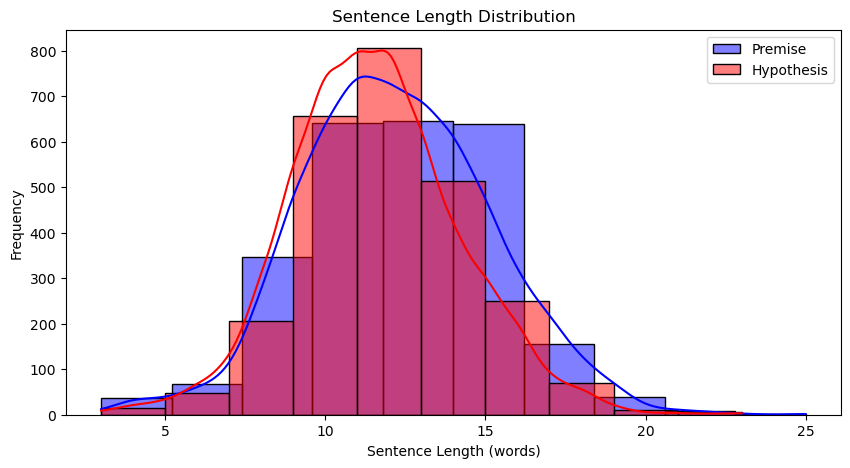

In [3]:
# Calculate sentence lengths (word count)
df['sentence_1_length'] = df['Premise'].apply(lambda x: len(x.split()))
df['sentence_2_length'] = df['Hypothesis'].apply(lambda x: len(x.split()))

# Plot the distribution of sentence lengths
plt.figure(figsize=(10, 5))
sns.histplot(df['sentence_1_length'], kde=True, color='blue', label='Premise', bins=10)
sns.histplot(df['sentence_2_length'], kde=True, color='red', label='Hypothesis', bins=10)
plt.title('Sentence Length Distribution')
plt.xlabel('Sentence Length (words)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [4]:
df['sentence_1_length'].head()#first 4 sentence length (word count)

0    15
1    13
2    14
3    14
4    15
Name: sentence_1_length, dtype: int64

In [5]:
df['sentence_2_length'].head()

0    16
1    10
2    15
3    10
4    15
Name: sentence_2_length, dtype: int64

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Get word frequencies
sentences = df['Premise'].tolist() + df['Hypothesis'].tolist()
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(sentences)
word_freq = X.sum(axis=0).A1
word_list = vectorizer.get_feature_names_out()
word_freq_dict = dict(zip(word_list, word_freq))
sorted_word_freq = sorted(word_freq_dict.items(), key=lambda x: x[1], reverse=True)
print("Most frequent words:", sorted_word_freq[:20])


Most frequent words: [('new', 234), ('team', 200), ('game', 178), ('used', 133), ('students', 117), ('using', 101), ('year', 101), ('coffee', 91), ('water', 86), ('focused', 84), ('local', 79), ('high', 77), ('company', 75), ('season', 73), ('use', 73), ('data', 72), ('organization', 72), ('time', 72), ('ocean', 70), ('players', 68)]


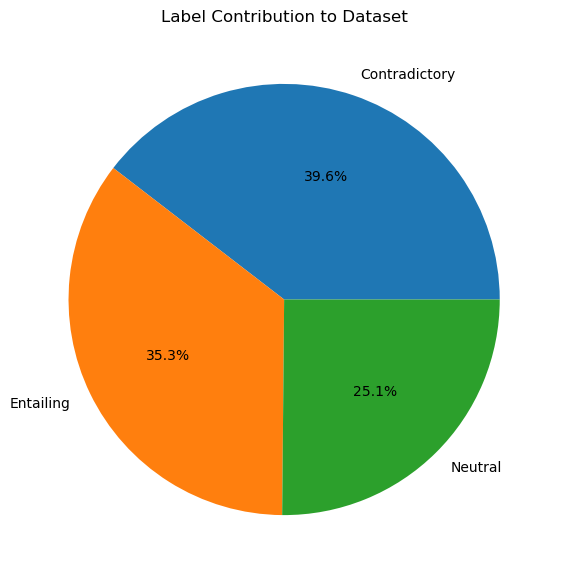

In [7]:
# Calculate the percentage contribution of each label
category_counts = df['Relationship'].value_counts(normalize=True) * 100
category_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title('Label Contribution to Dataset')
plt.ylabel('')  
plt.show()

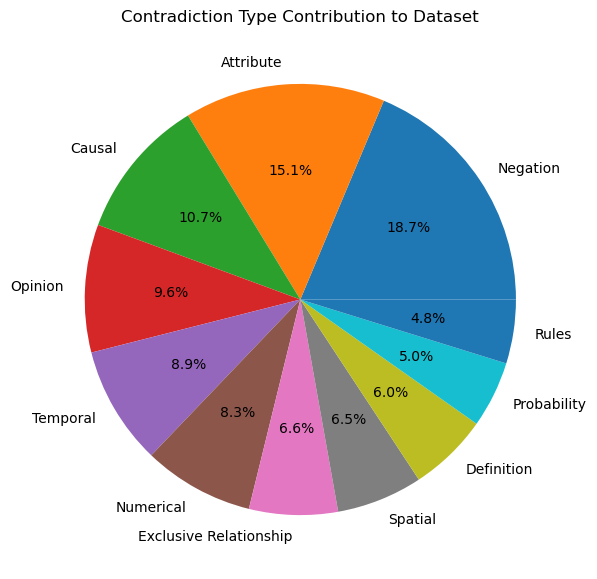

In [8]:
# Calculate the percentage contribution of each Contradiction Type label
category_counts = df['ContradictionType'].value_counts(normalize=True) * 100
category_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title('Contradiction Type Contribution to Dataset')
plt.ylabel('')  
plt.show()

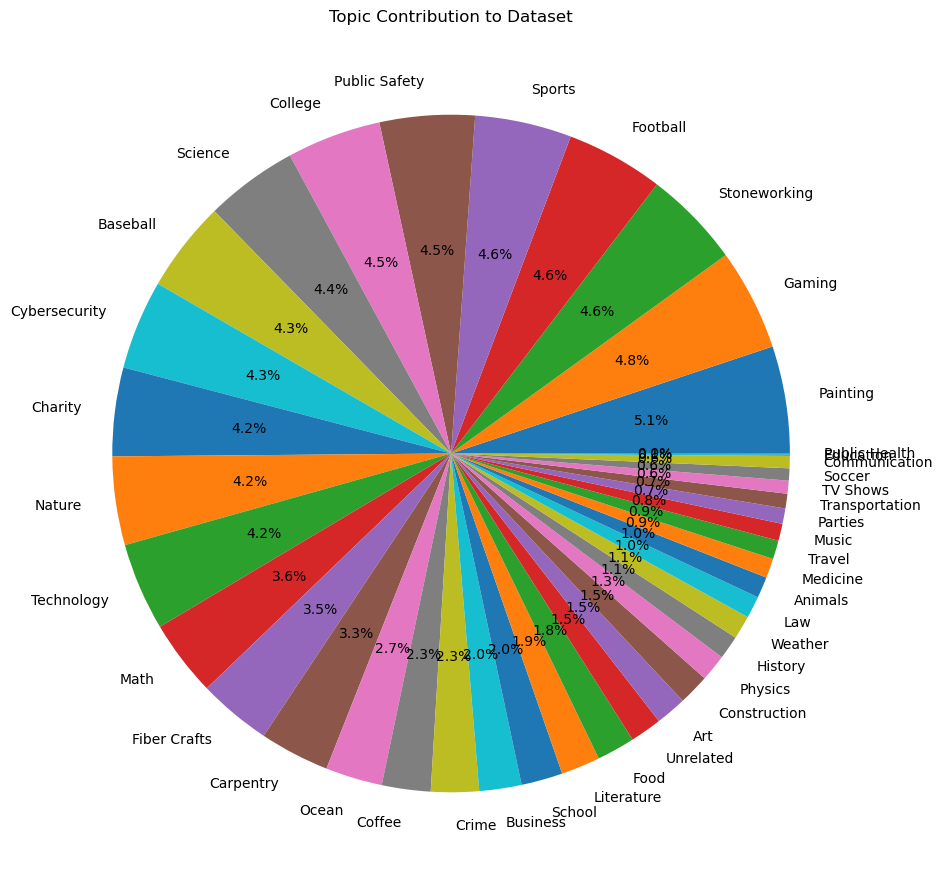

In [9]:
# Calculate the percentage contribution of each Contradiction Type label
category_counts = df['Subject'].value_counts(normalize=True) * 100
category_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(11, 11))
plt.title('Topic Contribution to Dataset')
plt.ylabel('')  
plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['Premise'] + " " + df['Hypothesis'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
high_similarity_pairs = np.where(cosine_sim > 0.9) 
similar_pairs = [(i, j) for i, j in zip(*high_similarity_pairs) if i != j]
print(f"Highly Similar Sentence Pairs (Similarity > 0.9): {similar_pairs}")

Highly Similar Sentence Pairs (Similarity > 0.9): [(60, 71), (64, 76), (71, 60), (76, 64), (2142, 2144), (2143, 2145), (2144, 2142), (2145, 2143)]


In [12]:
df.head()

,Premise,Hypothesis,Relationship,ContradictionType,Subject,Generated Relationship,Generated Contradiction type,sentence_1_length,sentence_2_length
0,The quantum processor developed by QTech Corp ...,The quantum processor from QTech Corp is limit...,Contradictory,Numerical,Technology,NaN,NaN,15,16
1,The new privacy update encrypts all user data ...,The new privacy update fails to encrypt any us...,Contradictory,Negation,Technology,NaN,NaN,13,10
2,The AI model was trained using a dataset consi...,The AI model was trained using diverse dataset...,Contradictory,Attribute,Technology,NaN,NaN,14,15
3,Tesla’s autopilot system was launched in 2015 ...,Tesla’s autopilot was introduced in 2022 after...,Contradictory,Temporal,Technology,NaN,NaN,14,10
4,The cloud server in Frankfurt ensures data is ...,The cloud server is located in Singapore to re...,Contradictory,Spatial,Technology,NaN,NaN,15,15


In [13]:
# Encode Relationship labels (contradiction -> 0, entailment -> 1, neutral -> 2)
label_map = {"Contradictory": 0, "Entailing": 1, "Neutral": 2}
df['Relationship'] = df['Relationship'].map(label_map)

# Encode Subject labels (Unrelated -> 0, Animals -> 1, Art -> 2, 
# Baseball -> 3, Business -> 4, Carpentry -> 5, Charity -> 6,
# Coffee -> 7, College -> 8, Communication -> 9, Construction -> 10,
# Crime -> 11, Cybersecurity -> 12, Fiber Crafts ->13, Food -> 14, 
# Football ->15, Gaming -> 16, History -> 17, Law -> 18, Literature -> 19,
# Math -> 20, Medicine -> 21, Music -> 22, Nature -> 23, Ocean ->24, 
# Painting -> 25, Parties -> 26, Physics -> 27, Public Health -> 28,
# Public Safety ->29, School -> 30, Science -> 31, Soccer -> 32,
#  Sports->33, Stoneworking ->34, Technology ->35, Transportation -> 36
# Travel -> 37, TV Shows ->38, Weather -> 39)
subject_map = {"Unrelated":0, "Animals":1, "Art":2, "Baseball":3, "Business":4, "Carpentry":5, "Charity":6, "Coffee":7, "College":8, "Communication":9, "Construction":10, "Crime":11, "Cybersecurity":12,"Fiber crafts":13, "Food":14, "Football":15, "Gaming":16, "History":17, "Law":18, "Literature":19, "Math":20, "Medicine":21, "Music":22, "Nature":23, "Ocean":24, "Painting":25, "Parties":26, "Physics":27, "Public Health":28,"Public Safety":29, "School":30, "Science":31, "Soccer":32, "Sports":33, "Stoneworking":34, "Technology":35, "Transportation":36, "Travel":37, "TV Shows":38, "Movie":38, "Weather":39} 
df['Subject'] = df['Subject'].map(subject_map)


print(df)

                                                Premise  \
0     The quantum processor developed by QTech Corp ...   
1     The new privacy update encrypts all user data ...   
2     The AI model was trained using a dataset consi...   
3     Tesla’s autopilot system was launched in 2015 ...   
4     The cloud server in Frankfurt ensures data is ...   
...                                                 ...   
2576  The team hosted a charity softball game during...   
2577  Some ballparks use natural grass while others ...   
2578  A player’s uniform number is often retired aft...   
2579  The scoreboard malfunctioned during the fourth...   
2580  While pitchers focus on velocity and command, ...   

                                             Hypothesis  Relationship  \
0     The quantum processor from QTech Corp is limit...             0   
1     The new privacy update fails to encrypt any us...             0   
2     The AI model was trained using diverse dataset...             0   

In [14]:
# First split into training and test sets train 90:train 10:test 
train_data, test_data = train_test_split(df, test_size=0.1, stratify=df['Relationship'])

# Then split the training data into training and validation sets
train_data, val_data = train_test_split(train_data, test_size=0.1, stratify=train_data['Relationship'])

# Print sizes of splits
print(f"Training Set Size: {len(train_data)}")
print(f"Validation Set Size: {len(val_data)}")
print(f"Test Set Size: {len(test_data)}")

Training Set Size: 2089
Validation Set Size: 233
Test Set Size: 259


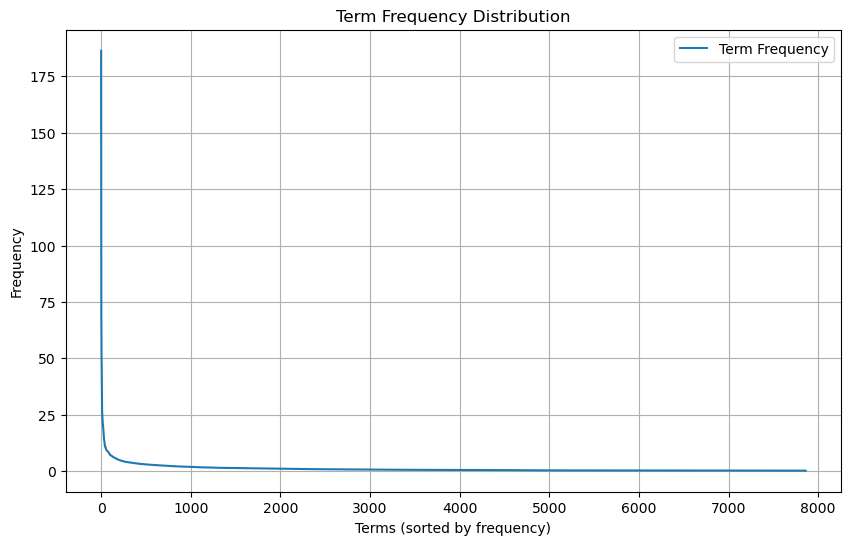

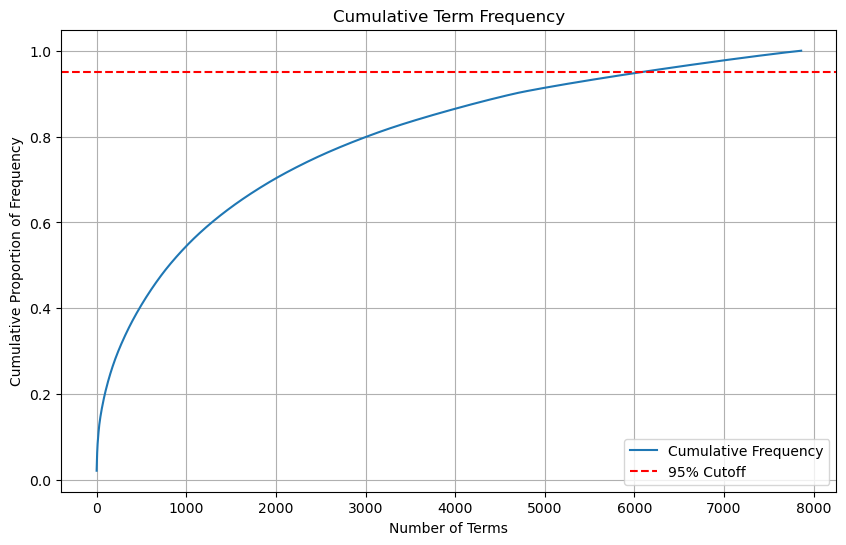

Top 6071 terms cover 95% of the cumulative frequency.


In [15]:
#Finding term frequency distribution and Cumulative Frequency with 95% cutoff 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer


train_texts = train_data['Premise'] + " " + train_data['Hypothesis']

#Vectorizing the text without max_features
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(train_texts)

#Aggregating term frequencies
term_frequencies = np.asarray(X.sum(axis=0)).flatten()  # Sum TF-IDF scores for each term
terms = vectorizer.get_feature_names_out()

#Combining terms with their frequencies
term_freq = sorted(zip(terms, term_frequencies), key=lambda x: x[1], reverse=True)
#print("Top terms by frequency:", term_freq)
#Visualizing the term frequencies
frequencies = [freq for term, freq in term_freq]
plt.figure(figsize=(10, 6))
plt.plot(frequencies, label='Term Frequency')
plt.title('Term Frequency Distribution')
plt.xlabel('Terms (sorted by frequency)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

#Analyzing cumulative frequency
cumulative_freq = np.cumsum(frequencies) / sum(frequencies)
plt.figure(figsize=(10, 6))
plt.plot(cumulative_freq, label='Cumulative Frequency')
plt.axhline(0.95, color='r', linestyle='--', label='95% Cutoff')
plt.title('Cumulative Term Frequency')
plt.xlabel('Number of Terms')
plt.ylabel('Cumulative Proportion of Frequency')
plt.legend()
plt.grid(True)
plt.show()

#95% cutoff
cutoff = np.argmax(cumulative_freq >= 0.95) + 1  # Terms that cover 95% of frequency
print(f"Top {cutoff} terms cover 95% of the cumulative frequency.")#to determine vectorizer = TfidfVectorizer(stop_words='english', max_features=2360 )

Cross-validation results:
Accuracy: Mean = 0.5237, Std = 0.0244
Precision_weighted: Mean = 0.5373, Std = 0.0228
Recall_weighted: Mean = 0.5237, Std = 0.0244
F1_weighted: Mean = 0.5084, Std = 0.0234

Validation Metrics:
Accuracy: 0.5150
Precision: 0.5070
Recall: 0.5150
F1-score: 0.5048
Confusion Matrix:
[[64 19  9]
 [33 36 13]
 [18 21 20]]

Test Metrics:
Accuracy: 0.5483
Precision: 0.5490
Recall: 0.5483
F1-score: 0.5354
Confusion Matrix:
[[79 21  3]
 [42 36 13]
 [20 18 27]]


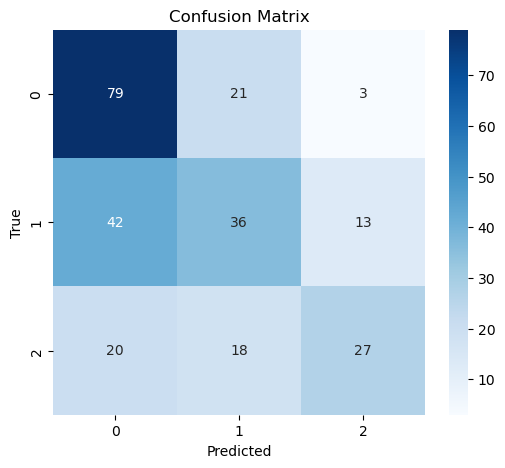

In [20]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import make_scorer, accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import cross_val_score, cross_validate
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder


# Extract features and labels from training, validation, and test data
X_train = train_data['Premise'] + " " + train_data['Hypothesis']  
y_train = train_data['Relationship']
X_val = val_data['Premise'] + " " + val_data['Hypothesis']
y_val = val_data['Relationship']
X_test = test_data['Premise'] + " " + test_data['Hypothesis']
y_test = test_data['Relationship']

# Convert text data to numerical features using TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english' , max_features=3575)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Encode labels 
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Initialize RandomForestClassifier
rf = RandomForestClassifier(random_state=42,n_jobs=-1)

# Perform Cross-Validation (CV)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = cross_validate(rf, X_train_tfidf, y_train_encoded, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)

# Print the cross-validation results
print(f"Cross-validation results:")
for score in scoring:
    print(f"{score.capitalize()}: Mean = {cv_results[f'test_{score}'].mean():.4f}, Std = {cv_results[f'test_{score}'].std():.4f}")

# Train the Random Forest model on the full training data
rf.fit(X_train_tfidf, y_train_encoded)

# Make predictions on the validation and test sets
y_val_pred = rf.predict(X_val_tfidf)
y_test_pred = rf.predict(X_test_tfidf)

# Evaluate the model
def print_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

# Print metrics for validation data
print("\nValidation Metrics:")
print_metrics(y_val_encoded, y_val_pred)

# Print metrics for test data
print("\nTest Metrics:")
print_metrics(y_test_encoded, y_test_pred)

# Confusion Matrix heatmap for test data
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [1]:
rf=LogisticRegression( random_state=42)

scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
cv_results = cross_validate(rf, X_train_tfidf, y_train_encoded, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)

# Print the cross-validation results
print(f"Cross-validation results:")
for score in scoring:
    print(f"{score.capitalize()}: Mean = {cv_results[f'test_{score}'].mean():.4f}, Std = {cv_results[f'test_{score}'].std():.4f}")

rf.fit(X_train_tfidf, y_train_encoded)

y_val_pred = rf.predict(X_val_tfidf)
y_test_pred = rf.predict(X_test_tfidf)

def print_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

# Print metrics for validation data
print("\nValidation Metrics:")
print_metrics(y_val_encoded, y_val_pred)

# Print metrics for test data
print("\nTest Metrics:")
print_metrics(y_test_encoded, y_test_pred)

# Confusion Matrix heatmap for test data
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

NameError: name 'LogisticRegression' is not defined

In [ ]:
rf=SVC(random_state=42)

scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = cross_validate(rf, X_train_tfidf, y_train_encoded, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)

# Print the cross-validation results
print(f"Cross-validation results:")
for score in scoring:
    print(f"{score.capitalize()}: Mean = {cv_results[f'test_{score}'].mean():.4f}, Std = {cv_results[f'test_{score}'].std():.4f}")

rf.fit(X_train_tfidf, y_train_encoded)

y_val_pred = rf.predict(X_val_tfidf)
y_test_pred = rf.predict(X_test_tfidf)

def print_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)


print("\nValidation Metrics:")
print_metrics(y_val_encoded, y_val_pred)


print("\nTest Metrics:")
print_metrics(y_test_encoded, y_test_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
rf=GradientBoostingClassifier(random_state=42)

scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = cross_validate(rf, X_train_tfidf, y_train_encoded, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)

# Print the cross-validation results
print(f"Cross-validation results:")
for score in scoring:
    print(f"{score.capitalize()}: Mean = {cv_results[f'test_{score}'].mean():.4f}, Std = {cv_results[f'test_{score}'].std():.4f}")

rf.fit(X_train_tfidf, y_train_encoded)

# Make predictions on the validation and test sets
y_val_pred = rf.predict(X_val_tfidf)
y_test_pred = rf.predict(X_test_tfidf)

# Evaluate the model
def print_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

# Print metrics for validation data
print("\nValidation Metrics:")
print_metrics(y_val_encoded, y_val_pred)

# Print metrics for test data
print("\nTest Metrics:")
print_metrics(y_test_encoded, y_test_pred)

# Confusion Matrix heatmap for test data
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
rf=MultinomialNB()

# Perform Cross-Validation (CV)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = cross_validate(rf, X_train_tfidf, y_train_encoded, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)

# Print the cross-validation results
print(f"Cross-validation results:")
for score in scoring:
    print(f"{score.capitalize()}: Mean = {cv_results[f'test_{score}'].mean():.4f}, Std = {cv_results[f'test_{score}'].std():.4f}")

rf.fit(X_train_tfidf, y_train_encoded)

# Make predictions on the validation and test sets
y_val_pred = rf.predict(X_val_tfidf)
y_test_pred = rf.predict(X_test_tfidf)

# Evaluate the model
def print_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

# Print metrics for validation data
print("\nValidation Metrics:")
print_metrics(y_val_encoded, y_val_pred)

# Print metrics for test data
print("\nTest Metrics:")
print_metrics(y_test_encoded, y_test_pred)

# Confusion Matrix heatmap for test data
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()